In [1]:
import sys
sys.path.append("/work/data1/GUOMENGKE/CuiYaxuan/NewDenoise/scSTADE-master/scSTADE_Cluster_Functions")
# Input the path.
from scSTADE import scSTADE
import os
import torch
import pandas as pd
import scanpy as sc
from sklearn import metrics
import multiprocessing as mp
import dropout

file = '/work/data1/GUOMENGKE/CuiYaxuan/NewDenoise/151507/' # Input the data path for the nonlinear model.
count='151507_filtered_feature_bc_matrix.h5' # Input the file name for the nonlinear model.
adata = sc.read_visium(file, count_file=count, load_images=True)

dropout.setup_seed(41)
dropout_rate=dropout.dropout(adata)
print(dropout_rate) # Data quality assessment.

device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu') # cpu or gpu
n_clusters = 7  # Users can input either the default number of clusters or the estimated number of clusters.


import rpy2.robjects as robjects

data_path = '/work/data1/GUOMENGKE/CuiYaxuan/NewDenoise/151507/151507_filtered_feature_bc_matrix.h5' # Input the data path and file name for the nonlinear model.
position_path = '/work/data1/GUOMENGKE/CuiYaxuan/NewDenoise/151507/spatial/tissue_positions_list.csv' # Input the data path and position file name for the nonlinear model.
ARI_compare='/work/data1/GUOMENGKE/CuiYaxuan/NewDenoise/151507/cluster_labels_151507.csv' #  Input the ground truth data path and file name for comparing with the clustering results

robjects.globalenv['data_path'] = robjects.vectors.StrVector([data_path])
robjects.globalenv['position_path'] = robjects.vectors.StrVector([position_path])
robjects.globalenv['ARI_compare'] = robjects.vectors.StrVector([ARI_compare])
robjects.globalenv['n_clusters'] = robjects.IntVector([n_clusters])



#The ARI accuracy and clustering labels have been generated and saved as CSV files.
if dropout_rate>0.85:
   for i in [4000, 4500, 5000]:
      file_fold = file
      adata = sc.read_visium(file_fold, count_file = count, load_images=True)
      adata.var_names_make_unique()
      model = scSTADE(adata,device=device,n_top_genes=i)
      adata = model.train()
      radius = 50
      tool = 'mclust' # mclust, leiden, and louvain
      from utils import clustering

      if tool == 'mclust':
         clustering(adata, n_clusters, radius=radius, method=tool, refinement=True) # For DLPFC dataset, we use optional refinement step.
      elif tool in ['leiden', 'louvain']:
         clustering(adata, n_clusters, radius=radius, method=tool, start=0.1, end=2.0, increment=0.01, refinement=False)

      adata.obs['domain']
      adata.obs['domain'].to_csv(f"label_{i}.csv")


   robjects.r('''
   library(SingleCellExperiment)
   library(SC3)
   library("Seurat")
   library("dplyr")
   library("hdf5r")
   library(foreach)
   library(doParallel)


   print(data_path)
   print(position_path)
   print(ARI_compare)
   print(n_clusters)

   source('/work/data1/GUOMENGKE/CuiYaxuan/NewDenoise/scSTADE-master/scSTADE_Cluster_Functions/Cri4.R')
   hc1= Read10X_h5(data_path) #### to your path and project name
   feature<-select_feature(hc1,4000,500)
   detectCores()
   cl <- makeCluster(3) # call 3 cpu cores
   k=n_clusters # k represent the number of spatial domains.
   parLapply(cl,1:3,feature=feature,k=k,pearson_metric) 
   stopCluster(cl)

   tissue_local=read.csv(position_path,row.names = 1,header = FALSE)
   adj_matrix=construct_adj_matrix(feature[[1]],tissue_local)
   write.table(adj_matrix,file="adj_matrix.txt",sep=" ",quote=TRUE)
   detectCores()
   cl <- makeCluster(3) # call 3 cpu cores
   parLapply(cl,1:3,K=k,spectral_nei)
   stopCluster(cl)



   source('/work/data1/GUOMENGKE/CuiYaxuan/NewDenoise/scSTADE-master/scSTADE_Cluster_Functions/GNN_Tradition_6.R')

   source('/work/data1/GUOMENGKE/CuiYaxuan/NewDenoise/scSTADE-master/scSTADE_Cluster_Functions/label_ARI.R')
   true_label=read.csv(ARI_compare,row.names = 1)
   conlabel(hc1,k,true_label,compare=T)        ####   compare=T is compare ARI with the ground truth, compare=F is no compare ARI with the ground truth.
            ''')
else:

   file_fold = file
   adata = sc.read_visium(file_fold, count_file= count, load_images=True)
   adata.var_names_make_unique()
   model = scSTADE(adata,device=device,n_top_genes=5000)
   adata = model.train()
   radius = 50
   tool = 'mclust' # mclust, leiden, and louvain
   from utils import clustering

   if tool == 'mclust':
      clustering(adata, n_clusters, radius=radius, method=tool, refinement=True) # For DLPFC dataset, we use optional refinement step.
   elif tool in ['leiden', 'louvain']:
      clustering(adata, n_clusters, radius=radius, method=tool, start=0.1, end=2.0, increment=0.01, refinement=False)

   adata.obs['domain']
   adata.obs['domain'].to_csv(f"label.csv")

/home/guomengke/anaconda3/envs/pipeline/lib/python3.8/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


0.9157111689540937
0.9157111689540937


Begin to train ST data...


  0%|          | 0/500 [00:00<?, ?it/s]

0


...

R[write to console]: *


R[write to console]: *


R[write to console]: *


R[write to console]: *


R[write to console]: |



#cells after MT filter: 4226


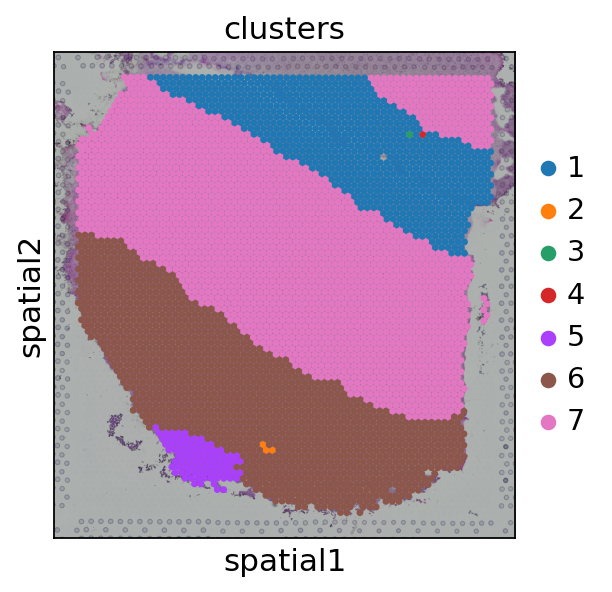

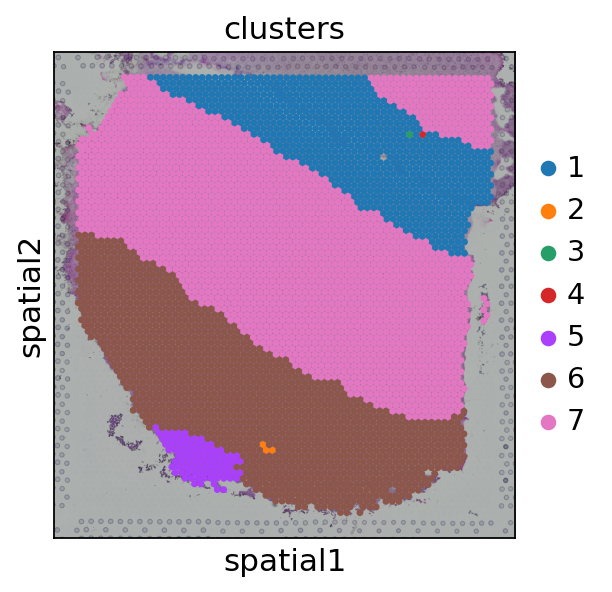

In [1]:

import matplotlib as mpl
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import visual
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams["font.sans-serif"] = "Arial"
warnings.filterwarnings('ignore')
file_fold = '/home/cuiyaxuan/spatialLIBD/151507/' # your path
adata = sc.read_visium(file_fold, count_file='151507_filtered_feature_bc_matrix.h5', load_images=True)
df_label=pd.read_csv('./label.csv', index_col=0) 
#df_label=pd.read_csv('./label_5000.csv', index_col=0) ##If the dropout rate is less than 0.85, visualize the data using "label_5000.csv".
visual.visual(adata,df_label)